<a href="https://www.kaggle.com/code/dmytrokan/notebookd716754039?scriptVersionId=356743526" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [61]:
from torchvision import datasets, transforms

In [62]:
paths = "/kaggle/input/datasets/sshikamaru/fruit-recognition/train/train"

In [63]:
dataset = datasets.ImageFolder(paths)

In [64]:
img, label = dataset[30]

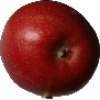

In [65]:
img

In [66]:
label

0

In [67]:
dataset.classes[label]

'Apple Braeburn'

In [68]:
from torch.utils.data import random_split

train_dataset, test_dataset = random_split(dataset, [0.8, 0.2])

In [69]:
from torchvision import transforms
train_transformer = transforms.Compose([
       transforms.Resize([128, 128]), 
       transforms.RandomHorizontalFlip(p=0.5),  
       transforms.RandomRotation(10),   
       transforms.ToTensor()  
])

test_transformer = transforms.Compose([
       transforms.Resize([128, 128]),
       transforms.ToTensor()
])

In [70]:
from torch.utils.data import Dataset,DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        img_new = self.transformer(img)

        return img_new, label

In [71]:
train_dataset = TransformDataset(train_dataset, train_transformer)
test_dataset = TransformDataset(test_dataset, test_transformer)

In [72]:
len(dataset.classes)

33

In [73]:
from torch.utils.data import Dataset,DataLoader

In [74]:
train_loader = DataLoader(train_dataset, batch_size = 120)
test_loader = DataLoader(test_dataset, batch_size = 120)

In [75]:
from torch import nn
128 * 128 * 3

49152

In [76]:
model = nn.Sequential(
    nn.Flatten(),  
    nn.Linear(49152, 200),
    nn.ReLU(),
    nn.Linear(200, 100),
    nn.ReLU(),
    nn.Linear(100, 50),
    nn.ReLU(),
    nn.Linear(50, 33)   
)

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CUDA unavailable")

In [77]:
model = model.to("cuda")

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
from torch.optim import Adam

loss_fn = nn.CrossEntropyLoss()

optimizer = Adam(
    model.parameters(),
    lr=0.001,
)

In [ ]:
epochs = 10
train_lost = []
test_lost = []
for _ in range(epochs):
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to("cuda")  
        y_batch = y_batch.to("cuda") 
    
        y_pred = model(X_batch)
    
        loss = loss_fn(y_pred, y_batch)
        train_lost.append(loss.item())
        print(loss.item())
    
        optimizer.zero_grad()   
        loss.backward()        
        optimizer.step() 
        
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to("cuda")  
        y_batch = y_batch.to("cuda") 
        y_pred = model(X_batch)

        loss = loss_fn(y_pred, y_batch)
        test_lost.append(loss.item())